# Stock Market prediction using Machine Learning
This project predicts stock market direction (Up/Down) using Machine Learning models and historical 
stock data from Yahoo Finance.

## Import Libraries
In this section, we import the required Python libraries for data collection, 
data analysis, visualization, and machine learning.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Collection
In this section, This project uses 
**synthetic (simulated) financial data** 
generated to mimic real market behavior.

In [2]:
import pandas as pd

df = pd.read_csv(
    "yahoo_like_2020_2025.csv",
    header=[0,1],
    index_col=0,
    parse_dates=True
)

df = df["AAPL"]

print(df.head())

                  Open        High         Low       Close   Adj Close  \
2020-01-01  151.588686  152.322359  151.357782  151.580142  151.580142   
2020-01-02  151.249170  151.259965  150.205062  151.251928  151.251928   
2020-01-03  153.634902  154.870886  151.853222  153.301962  153.301962   
2020-01-06  158.213678  159.436368  156.984764  158.063613  158.063613   
2020-01-07  157.410349  158.281540  156.888350  157.418228  157.418228   

              Volume  
2020-01-01   7232190  
2020-01-02  12831900  
2020-01-03   9920337  
2020-01-06  14031499  
2020-01-07   4154828  


## Features Engineering
We create several features from historical stock data, including:
- Daily returns
- Moving averages 
- Volatility
- Volume changes

In [3]:
# Daily Return
df["Return"] = df["Close"].pct_change()

# Moving Averages
df["MA5"] = df["Close"].rolling(5).mean()
df["MA10"] = df["Close"].rolling(10).mean()

# Lag Features
df["Return_lag1"] = df["Return"].shift(1)
df["Return_lag2"] = df["Return"].shift(2)

# Volatility
df["Volatility"] = df["Return"].rolling(5).std()

# Volume Change
df["Volume_change"] = df["Volume"].pct_change()

## Create Target Variable
The target variable represents wether the stock price goes up ot down the next day.
    - 1 = price goes up
    - 0 = price goes down

In [4]:
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)


## Data Cleaning
Rows containing missing values are removed before training the model.

In [5]:
df = df.dropna()

## Define Features and Target
The features variables are used as model inputs, while the target variable is the prediction output.

In [6]:
features = ["Return",
            "MA5",
            "MA10",
            "Return_lag1",
            "Return_lag2",
            "Volatility",
            "Volume_change"]
x = df[features]
y = df["Target"]

## Train-Test Split
The dataset is divided into training and testing sets.
since stock data is time-series data, shuffling is disabled.

In [7]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, shuffle=False)

## Logistic Regression Model
Logestic Regression is used as a baseline classification model.

In [8]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train, y_train)
pred = model.predict(x_test)
print(pred[:10])

[1 1 1 1 1 1 1 1 1 1]


## Random Forest Model
Random Forest is an ensemble  learning algorithm based on multiple decision trees.

In [9]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)
pred = model.predict(x_test)

## Model Evaluation
We evaluate the model using:
- Accuracy score
- Confusion matrix
- Classification report

In [10]:
from sklearn.metrics import (
accuracy_score,
confusion_matrix,
classification_report
)
accuracy = accuracy_score(y_test, pred)
print("Accuracy:", accuracy)
cm = confusion_matrix(y_test, pred)
print(cm)
print(classification_report(y_test, pred))

Accuracy: 0.5076923076923077
[[61 59]
 [69 71]]
              precision    recall  f1-score   support

           0       0.47      0.51      0.49       120
           1       0.55      0.51      0.53       140

    accuracy                           0.51       260
   macro avg       0.51      0.51      0.51       260
weighted avg       0.51      0.51      0.51       260



## Stock Price Visualization
This chart shows the historical closing prices of the stock.

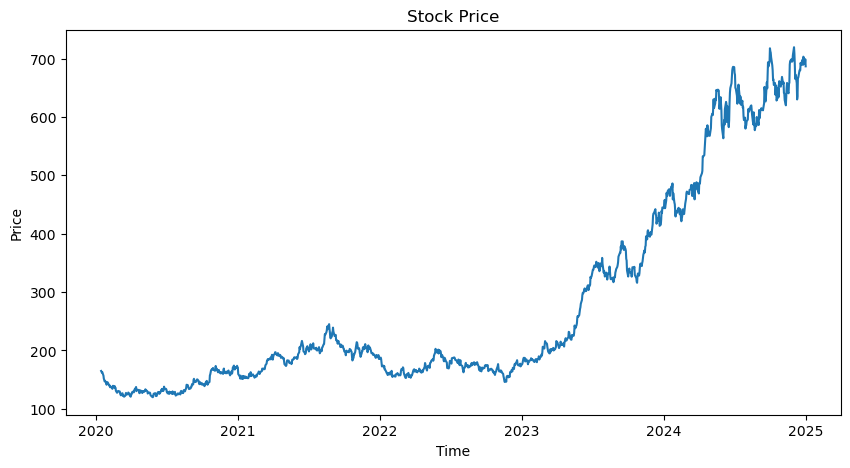

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(df["Close"])
plt.title("Stock Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.savefig("stock-price-pic")
plt.show()

## Prediction Visualization 
This chart compares real market direction with model predictions.

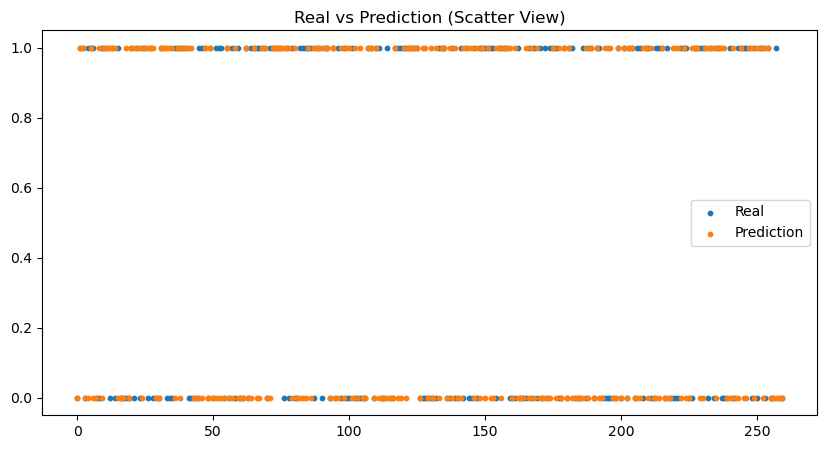

In [12]:
plt.figure(figsize=(10,5))

plt.scatter(range(len(y_test)), y_test, label="Real", s=10)
plt.scatter(range(len(pred)), pred, label="Prediction", s=10)

plt.legend()
plt.title("Real vs Prediction (Scatter View)")
plt.savefig("stock-price-pred")
plt.show()

## Features Importance
Random Forest provides feature importance scores that indicate the influence of each feature on predictions.

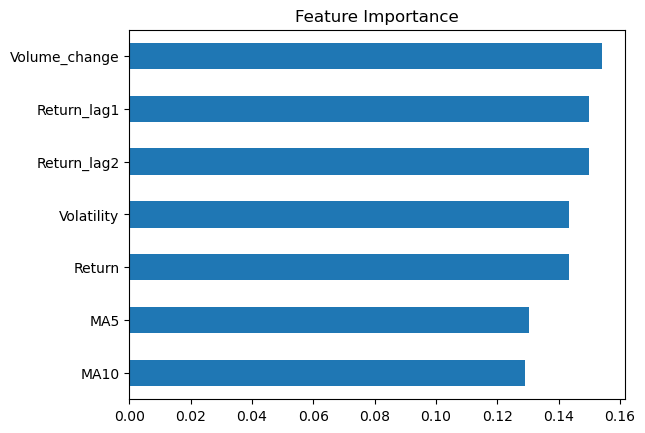

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model.feature_importances_
feat_importance = pd.Series(importance, index=features) 
feat_importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.savefig("feature-importanc-pic")
plt.show()
